In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, expon, poisson, probplot

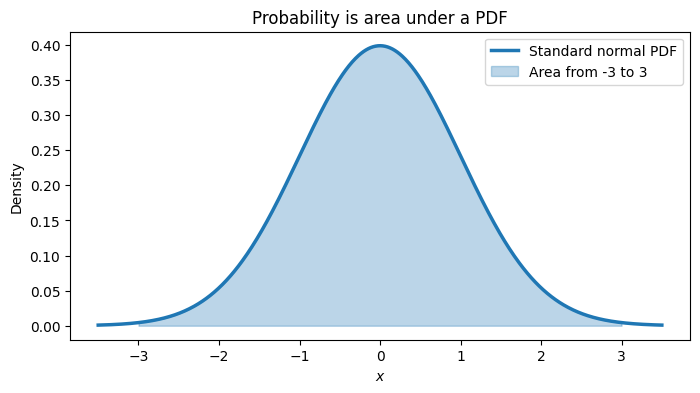

P(-3 < Z < 3) = 0.9973
P(Z = 0) = 0.0


In [4]:
# code 1

# For a continuous variable, probability is area under the PDF.
Z = norm(loc=0, scale=1)
a, b = -3, 3
x = np.linspace(-3.5, 3.5, 700)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, Z.pdf(x), color="C0", linewidth=2.5, label="Standard normal PDF")
inside = (x >= a) & (x <= b)
ax.fill_between(x[inside], 0, Z.pdf(x[inside]), color="C0", alpha=0.30,
                label=rf"Area from {a} to {b}")
ax.set(xlabel="$x$", ylabel="Density", title="Probability is area under a PDF")
ax.legend()
plt.show()

interval_probability = Z.cdf(b) - Z.cdf(a)
point_probability = Z.cdf(0) - Z.cdf(0)
print(f"P({a} < Z < {b}) = {interval_probability:.4f}")
print(f"P(Z = 0) = {point_probability:.1f}")


P(D <= 3) = 0.2500
P(4 < D < 9) = 0.4167
P(D > 10) = 0.1667
Mean = 6.00 seconds
Variance = 12.0000 seconds^2
95th percentile = 11.40 seconds


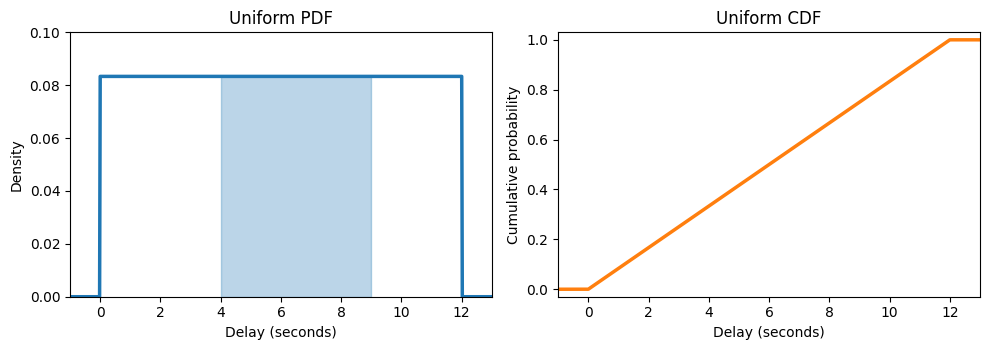

In [5]:
# code 2

# Delay until the next sensor poll: D ~ Uniform(0, 12)
D = uniform(loc=0, scale=12)  # loc=a, scale=b-a

print(f"P(D <= 3) = {D.cdf(3):.4f}")
print(f"P(4 < D < 9) = {D.cdf(9) - D.cdf(4):.4f}")
print(f"P(D > 10) = {D.sf(10):.4f}")
print(f"Mean = {D.mean():.2f} seconds")
print(f"Variance = {D.var():.4f} seconds^2")
print(f"95th percentile = {D.ppf(0.95):.2f} seconds")

d = np.linspace(-1, 13, 700)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(d, D.pdf(d), color="C0", linewidth=2.5)
axes[0].fill_between(d, 0, D.pdf(d), where=(d >= 4) & (d <= 9),
                     color="C0", alpha=0.30)
axes[0].set(title="Uniform PDF", xlabel="Delay (seconds)", ylabel="Density",
            xlim=(-1, 13), ylim=(0, 0.10))
axes[1].plot(d, D.cdf(d), color="C1", linewidth=2.5)
axes[1].set(title="Uniform CDF", xlabel="Delay (seconds)",
            ylabel="Cumulative probability", xlim=(-1, 13), ylim=(-0.03, 1.03))
plt.tight_layout()
plt.show()


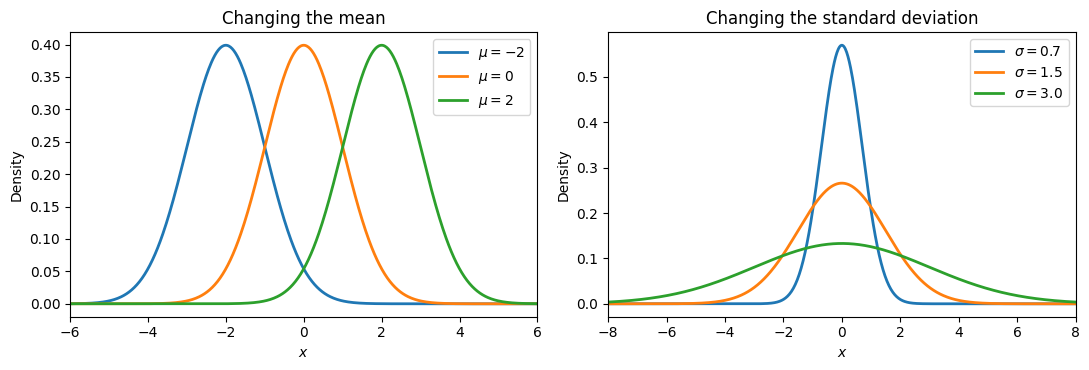

P(-1 < Z < 1) = 0.6827
P(-2 < Z < 2) = 0.9545
P(-3 < Z < 3) = 0.9973


In [6]:
# code 3

x = np.linspace(-8, 12, 900)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Changing mu moves the distribution but does not change its shape.
for mu in (-2, 0, 2):
    model = norm(loc=mu, scale=1)
    axes[0].plot(x, model.pdf(x), linewidth=2, label=rf"$\mu={mu}$")
axes[0].set(title="Changing the mean", xlabel="$x$", ylabel="Density", xlim=(-6, 6))
axes[0].legend()

# Changing sigma changes the spread.
for sigma in (0.7, 1.5, 3.0):
    model = norm(loc=0, scale=sigma)
    axes[1].plot(x, model.pdf(x), linewidth=2, label=rf"$\sigma={sigma}$")
axes[1].set(title="Changing the standard deviation", xlabel="$x$",
            ylabel="Density", xlim=(-8, 8))
axes[1].legend()
plt.tight_layout()
plt.show()

standard_normal = norm()
for k in (1, 2, 3):
    probability = standard_normal.cdf(k) - standard_normal.cdf(-k)
    print(f"P(-{k} < Z < {k}) = {probability:.4f}")

In [7]:
# code 4

# Worked response-time model: X ~ N(110, 15^2) ms
X = norm(loc=110, scale=15)

z_140 = (140 - 110) / 15
print(f"z-score for 140 ms = {z_140:.2f}")
print(f"P(X > 140) = {X.sf(140):.4f}")
print(f"P(Z > 2) = {norm.sf(z_140):.4f}")
print(f"P(95 < X < 125) = {X.cdf(125) - X.cdf(95):.4f}")
print(f"95th percentile = {X.ppf(0.95):.2f} ms")


z-score for 140 ms = 2.00
P(X > 140) = 0.0228
P(Z > 2) = 0.0228
P(95 < X < 125) = 0.6827
95th percentile = 134.67 ms


n = 60
Fitted model: N(118.53, 196.89)
SciPy scale = 14.03 ms
Model P(X > 140) = 0.0630
Observed proportion above 140 = 0.0500
Model 95th percentile = 141.61 ms
z-score for 140 ms = 1.53


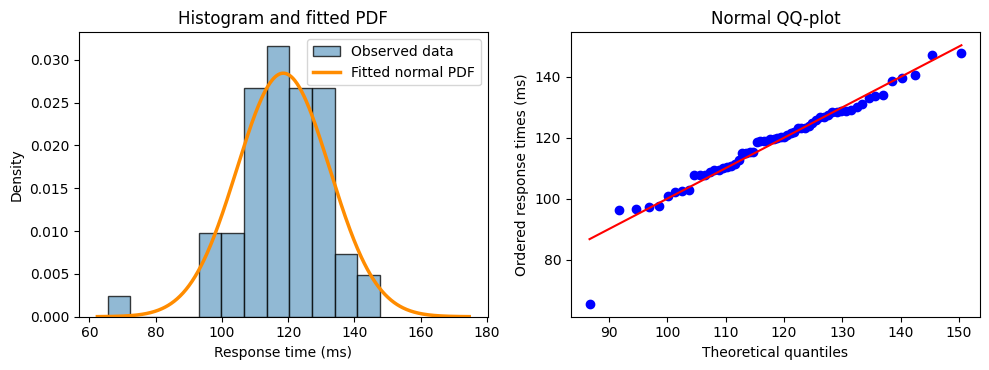

In [8]:
# code 5

# Find the data file whether the notebook starts here or in the repository root.
search_folders = (Path.cwd(), *Path.cwd().parents)
response_file = next(
    (folder / "data" / "response_times.csv" for folder in search_folders
     if (folder / "data" / "response_times.csv").exists()),
    None,
)
if response_file is None:
    raise FileNotFoundError("Could not find data/response_times.csv")

times = pd.read_csv(response_file)["server_a_ms"]
mu_hat = times.mean()
sigma_hat = times.std(ddof=1)
fitted_normal = norm(loc=mu_hat, scale=sigma_hat)

print(f"n = {len(times)}")
print(f"Fitted model: N({mu_hat:.2f}, {sigma_hat**2:.2f})")
print(f"SciPy scale = {sigma_hat:.2f} ms")
print(f"Model P(X > 140) = {fitted_normal.sf(140):.4f}")
print(f"Observed proportion above 140 = {(times > 140).mean():.4f}")
print(f"Model 95th percentile = {fitted_normal.ppf(0.95):.2f} ms")
print(f"z-score for 140 ms = {(140 - mu_hat) / sigma_hat:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
xs = np.linspace(mu_hat - 4 * sigma_hat, mu_hat + 4 * sigma_hat, 500)
axes[0].hist(times, bins=12, density=True, edgecolor="black",
             color="#6CA2C6", alpha=0.75, label="Observed data")
axes[0].plot(xs, fitted_normal.pdf(xs), color="#FF8C00", linewidth=2.5,
             label="Fitted normal PDF")
axes[0].set(title="Histogram and fitted PDF", xlabel="Response time (ms)",
            ylabel="Density")
axes[0].legend()

probplot(times, dist=fitted_normal, plot=axes[1])
axes[1].set_title("Normal QQ-plot")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Ordered response times (ms)")
plt.tight_layout()
plt.show()


Mean = 5.00 hours
Variance = 25.00 hours^2
P(T > 8) = 0.2019
P(T <= 3) = 0.4512
Median = 3.47 hours
90th percentile = 11.51 hours


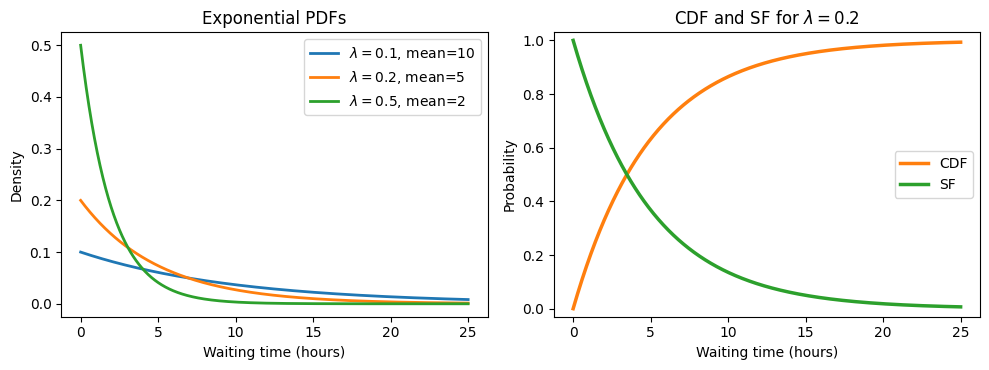

In [9]:
# code 6

# Time until the next production stop with rate 0.2 per hour.
rate = 0.2
T = expon(scale=1 / rate)  # SciPy scale is the mean 1/rate

print(f"Mean = {T.mean():.2f} hours")
print(f"Variance = {T.var():.2f} hours^2")
print(f"P(T > 8) = {T.sf(8):.4f}")
print(f"P(T <= 3) = {T.cdf(3):.4f}")
print(f"Median = {T.ppf(0.50):.2f} hours")
print(f"90th percentile = {T.ppf(0.90):.2f} hours")

t = np.linspace(0, 25, 700)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for current_rate in (0.1, 0.2, 0.5):
    model = expon(scale=1 / current_rate)
    axes[0].plot(t, model.pdf(t), linewidth=2,
                 label=rf"$\lambda={current_rate}$, mean={1/current_rate:.0f}")
axes[0].set(title="Exponential PDFs", xlabel="Waiting time (hours)", ylabel="Density")
axes[0].legend()

axes[1].plot(t, T.cdf(t), color="C1", linewidth=2.5, label="CDF")
axes[1].plot(t, T.sf(t), color="C2", linewidth=2.5, label="SF")
axes[1].set(title=rf"CDF and SF for $\lambda={rate}$", xlabel="Waiting time (hours)",
            ylabel="Probability", ylim=(-0.03, 1.03))
axes[1].legend()
plt.tight_layout()
plt.show()


In [10]:
# code 7

# Memorylessness: P(T > s+t | T > s) = P(T > t)
s = 3
additional_time = 4
conditional_probability = T.sf(s + additional_time) / T.sf(s)
fresh_wait_probability = T.sf(additional_time)

print(f"P(T > 7 | T > 3) = {conditional_probability:.4f}")
print(f"P(T > 4) = {fresh_wait_probability:.4f}")

# Poisson count and exponential waiting time describe the same constant-rate mechanism.
hours = 8
N_8 = poisson(mu=rate * hours)
print(f"Exponential P(T > 8) = {T.sf(hours):.4f}")
print(f"Poisson P(N(8) = 0) = {N_8.pmf(0):.4f}")


P(T > 7 | T > 3) = 0.4493
P(T > 4) = 0.4493
Exponential P(T > 8) = 0.2019
Poisson P(N(8) = 0) = 0.2019
